In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)
from sequenceHandler import distance_map_PDB
import torch.nn as nn
from torch_geometric.nn import MessagePassing, LayerNorm
import torch.nn.functional as F
from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve, precision_recall_curve
from torch_geometric.utils import softmax

1924702


In [2]:
folder_DCA="Data"
folder_PDB="PDB"
thres=8.0
learning_rate=0.01
minimum_separation=0

In [3]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [4]:
def contact_from_distance(distance_map, threshold=thres):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  

#function to take the top k element of a matrix (excludin the ones masked) 
def top_k_mask(matrix, k, mask=None):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    if mask is not None:
        mask_vals = mask[triu_indices]
        #make the masked point distant -inf
        values = np.where(mask_vals, values, -np.inf)

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask_out = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask_out[rows, cols] = 1
    mask_out[cols, rows] = 1

    return mask_out

In [5]:
#taking the probability distribution of the contacts this function make noisy PDB

def sample_noisy_contact_map_from_distance(
    distance_map,
    p_detect_by_r,
    K,
    threshold=thres,
    seed=None,
):
    """
    Generate a noisy contact map using detection probabilities vs real distance.

    Parameters
    ----------
    distance_map : (L, L) array
        Real-valued distance matrix.
    p_detect_by_r : array-like
        p_detect_by_r[r] = probability of predicting a contact at distance r
        (r is assumed to be int(distance)).
    K : int
        Total number of predicted contacts
    threshold : float
        Distance threshold separating true (<= threshold) and false (> threshold).
    seed : int or None

    Returns
    -------
    new_map : (L, L) int8 array
    stats : dict
        Contains counts of true/false contacts.
    """
    rng = np.random.default_rng(seed)

    D = np.asarray(distance_map)
    L = D.shape[0]

    # --- consider only upper triangle (i < j)
    i, j = np.triu_indices(L, k=1)

    dvals = D[i, j]
    valid = np.isfinite(dvals)

    i = i[valid]
    j = j[valid]
    dvals = dvals[valid]

    # --- convert distances to integer bins
    r = np.floor(dvals).astype(int)
    r = np.clip(r, 0, len(p_detect_by_r) - 1)

    # --- weights from empirical detection probability
    w = p_detect_by_r[r].astype(float)

    # avoid degenerate case
    if np.all(w == 0):
        raise ValueError("All detection probabilities are zero.")

    # --- split into true / false according to threshold
    true_mask = dvals <= threshold
    false_mask = dvals > threshold

    # weights per group
    w_true = w[true_mask]
    w_false = w[false_mask]

    # --- total weight
    W_true = w_true.sum()
    W_false = w_false.sum()
    W_total = W_true + W_false

    if W_total == 0:
        raise ValueError("Total weight is zero.")

    # --- allocate number of contacts
    K_true = int(round(K * W_true / W_total))
    K_false = K - K_true

    # --- indices
    true_i, true_j = i[true_mask], j[true_mask]
    false_i, false_j = i[false_mask], j[false_mask]

    # --- safety checks
    K_true = min(K_true, len(true_i))
    K_false = min(K_false, len(false_i))

    # --- probabilities within each group
    if len(w_true) > 0:
        p_true = w_true / w_true.sum()
        idx_true = rng.choice(len(true_i), size=K_true, replace=False, p=p_true)
    else:
        idx_true = np.array([], dtype=int)

    if len(w_false) > 0:
        p_false = w_false / w_false.sum()
        idx_false = rng.choice(len(false_i), size=K_false, replace=False, p=p_false)
    else:
        idx_false = np.array([], dtype=int)

    # --- build output map
    new_map = np.zeros((L, L), dtype=np.int8)

    # true contacts
    ti = true_i[idx_true]
    tj = true_j[idx_true]
    new_map[ti, tj] = 1
    new_map[tj, ti] = 1

    # false contacts
    fi = false_i[idx_false]
    fj = false_j[idx_false]
    new_map[fi, fj] = 1
    new_map[fj, fi] = 1

    stats = {
        "K_total": K,
        "K_true": len(idx_true),
        "K_false": len(idx_false),
        "fraction_true": len(idx_true) / K if K > 0 else 0.0,
    }

    return new_map, stats

In [6]:
#how to store the data

def build_graph_contact(noisy_contact_map, distance_map=None, sep_min=minimum_separation):
    
    N = len(noisy_contact_map)

    # contact map to tensor
    noisy_contact_map = torch.tensor(noisy_contact_map, dtype=torch.float)

    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if distance_map is not None:
        known = np.isfinite(distance_map)
        known = torch.tensor(known, dtype=torch.bool)
        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        true_contact_map = torch.tensor(true_contact_map, dtype=torch.float)
        labels = (known & (true_contact_map == 1)).float()

        distance_map = torch.tensor(distance_map, dtype=torch.float)
        distance_map=torch.log((distance_map)/8) #renormalization to see again when we have more data
        labels_distance = distance_map
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)
        labels_distance = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok
     # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    edge_index = torch.stack([src, dst], dim=0)
    edge_attr = noisy_contact_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1) 

    y_distances= labels_distance[valid].unsqueeze(-1) 

        
    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,                 # binary contact labels
        y_dist=y_distances,
        edge_mask=mask,      # valid + long-range
        pair_mask=pair_mask, # only one direction per pair
        L=N
    )

In [7]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [8]:
def model_size(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )

    print(f"Total parameters:      {total_params:,}")
    print(f"Trainable parameters:  {trainable_params:,}")
    print(f"Non-trainable params:  {total_params - trainable_params:,}")

In [9]:
class AttentionMPLayer(MessagePassing):
    """Single attention-based message-passing layer (node + edge updates)."""

    def __init__(self, hidden_dim, heads=4, dropout=0.0):
        super().__init__(node_dim=0, aggr='add', flow='source_to_target')

        self.hidden_dim = hidden_dim
        self.heads = heads
        self.head_dim = hidden_dim // heads
        self.dropout = dropout

        assert hidden_dim % heads == 0, "hidden_dim must be divisible by heads"

        # Edge update MLP: [x_i, x_j, e_ij] -> e'_ij
        self.edge_mlp = nn.Sequential(
            nn.Linear(3 * hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # Attention projections (Q, K spaces)
        self.att_lin_i = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)
        self.att_lin_j = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)
        self.att_lin_e = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)
        self.att_vec = nn.Parameter(torch.Tensor(1, heads, self.head_dim))

        # Message projections (V space)
        self.pay_lin_j = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)
        self.pay_lin_e = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)

        # Node update MLP: [x_i, aggregated_messages] -> x'_i
        self.node_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.att_lin_i.weight)
        nn.init.xavier_uniform_(self.att_lin_j.weight)
        nn.init.xavier_uniform_(self.att_lin_e.weight)
        nn.init.xavier_uniform_(self.pay_lin_j.weight)
        nn.init.xavier_uniform_(self.pay_lin_e.weight)
        nn.init.xavier_uniform_(self.att_vec)

    def forward(self, x, edge_index, edge_attr):
        edge_attr_new = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        message = self.propagate(edge_index, x=x, edge_attr=edge_attr_new)
        x_new = self.node_mlp(torch.cat([x, message], dim=-1))
        return x_new, edge_attr_new

    def edge_update(self, x_i, x_j, edge_attr):
        return self.edge_mlp(torch.cat([x_i, x_j, edge_attr], dim=-1))

    def message(self, x_i, x_j, edge_attr, index, ptr, size_i):
        q_i = self.att_lin_i(x_i).view(-1, self.heads, self.head_dim)
        k_j = self.att_lin_j(x_j).view(-1, self.heads, self.head_dim)
        k_e = self.att_lin_e(edge_attr).view(-1, self.heads, self.head_dim)

        score = F.leaky_relu(q_i + k_j + k_e, 0.2)
        alpha = (score * self.att_vec).sum(dim=-1)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        v_j = self.pay_lin_j(x_j).view(-1, self.heads, self.head_dim)
        v_e = self.pay_lin_e(edge_attr).view(-1, self.heads, self.head_dim)
        return (v_j + v_e) * alpha.unsqueeze(-1)

    def update(self, inputs, x):
        return inputs.view(-1, self.heads * self.head_dim)


class MP_GNN(nn.Module):
    """
    Attention MPNN for edge classification + SAGE contrastive learning.

    Returns (x_sage, out_reg, out_cls):
      x_sage   — L2-normalized node embeddings at layer num_layers_sage (for SAGE loss)
      out_reg  — per-edge regression logits [E]
      out_cls  — per-edge classification logits [E]
    """

    def __init__(self, num_layers=6, num_heads=2,
                 node_in_dim=16, edge_in_dim=16, latent_dim=32):
        super().__init__()

        assert latent_dim % num_heads == 0, "latent_dim must be divisible by num_heads"

        
        self.node_in_dim = node_in_dim
        self.edge_in_dim = edge_in_dim

        self.in_x_proj = nn.Linear(node_in_dim, latent_dim)
        self.in_e_proj = nn.Linear(edge_in_dim, latent_dim)

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList()
        self.edge_norms = nn.ModuleList()
        for _ in range(num_layers):
            self.node_norms.append(LayerNorm(latent_dim))
            self.edge_norms.append(LayerNorm(latent_dim))
            self.convs.append(AttentionMPLayer(hidden_dim=latent_dim, heads=num_heads, dropout=0.1))

        self.out_cls = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(latent_dim, 1)
        )


        self.out_reg = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(latent_dim, 1)
        )


    def forward(self, graph):
        x, edge_index, edge_attr = graph.x, graph.edge_index, graph.edge_attr

        x = self.in_x_proj(x)
        edge_attr = self.in_e_proj(edge_attr)

        for i, (conv, node_norm, edge_norm) in enumerate(zip(self.convs, self.node_norms, self.edge_norms)):
            x = node_norm(x)
            edge_attr = edge_norm(edge_attr)
            x_new, edge_attr_new = conv(x, edge_index, edge_attr)
            x = x + x_new
            edge_attr = edge_attr + edge_attr_new

        out_cls = self.out_cls(edge_attr).squeeze(-1)
        out_reg = self.out_reg(edge_attr).squeeze(-1)
        return out_cls, out_reg

In [10]:
#how to evaluate the precision of the top kL contact for each graph
def topk_L_precision(model, loader, device, ratio=1.0):
    model.eval()
    per_graph_precisions = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)

            probs = torch.sigmoid(logits.squeeze(-1))
            true_contacts = batch.y.squeeze(-1)

            valid_mask = batch.edge_mask & batch.pair_mask

            # graph id for each edge
            edge_graph_id = batch.batch[batch.edge_index[0]]

            num_graphs = batch.num_graphs

            for g in range(num_graphs):
                graph_mask = valid_mask & (edge_graph_id == g)

                probs_g = probs[graph_mask]
                true_g = true_contacts[graph_mask]

                if probs_g.numel() == 0:
                    continue

                # length of the protein
                L = int(batch.L[g]) if torch.is_tensor(batch.L) else int(batch.L)

                k = max(1, int(L * ratio))
                k = min(k, probs_g.numel())

                top_idx = torch.topk(probs_g, k=k).indices
                #knumber of true contacts in top-k​/k
                precision_g = (true_g[top_idx] > 0.5).float().mean().item()

                per_graph_precisions.append(precision_g)

    return float(np.mean(per_graph_precisions)), per_graph_precisions

In [11]:
def graph_to_matrix(data, values):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

In [12]:
class AsymmetricLoss(nn.Module):
    def __init__(
        self,
        gamma_neg=6,
        gamma_pos=1,
        clip=0.05,
        eps=1e-8
    ):
        super().__init__()

        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        # optional clipping
        if self.clip is not None and self.clip > 0:
            probs_neg = (1 - probs + self.clip).clamp(max=1)
        else:
            probs_neg = 1 - probs

        pos_loss = targets * torch.log(probs.clamp(min=self.eps))
        neg_loss = (1 - targets) * torch.log(
            probs_neg.clamp(min=self.eps)
        )

        pos_weight = (1 - probs) ** self.gamma_pos
        neg_weight = probs ** self.gamma_neg

        loss = -(
            pos_weight * pos_loss
            + neg_weight * neg_loss
        )

        return loss.mean()

<- functions and class

In [13]:
folder_path = folder_DCA

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

In [18]:
#Take statistical information from the dca data, for each distance the total number of link, true postive and false positive is annotated

stats=np.zeros((300,3))


for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=thres)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)

    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            if isfinite[i][j]:

                d = int(dist[i, j])
                stats[d, 2] += 1  # total pairs at distance d

                if binary_map[i, j]==1:

                    if contact_map[i, j]==1:
                        #true positives
                        stats[d, 0] += 1

                    elif contact_map[i, j]==0:
                        #false positives
                        stats[d, 1] += 1
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)

/tmp/ipykernel_1899462/3618472091.py:40: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_1899462/3618472091.py:41: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


In [19]:
#data import

folder_path = folder_PDB
p_detect_by_r = total_percentage

all_data = []
for file in os.listdir(folder_path):
    pdb_path = os.path.join(folder_path, file)
    chain_id = "A"
    output_map_file = "None"  

    try:
        distance_map, __ = distance_map_PDB(pdb_path, chain_id, output_map_file)

        L= distance_map.shape[0]
        K = 5 * L
        noisy_contact_map, __ = sample_noisy_contact_map_from_distance(distance_map,p_detect_by_r,K,threshold=thres,seed=1)
        data = build_graph_contact(noisy_contact_map, distance_map,minimum_separation)
        all_data.append(data)
    except:
        print(f"Some error occurred in the sequence {file}")


torch.save(all_data, "all_data_likeDCA_sep0+regression.pt") 

Some error occurred in the sequence PF07714.pdb
Some error occurred in the sequence PF00016.pdb
Some error occurred in the sequence PF00031.pdb
Some error occurred in the sequence PF00044.pdb
Some error occurred in the sequence PF00046.pdb
Some error occurred in the sequence PF00050.pdb
Some error occurred in the sequence PF00058.pdb
Some error occurred in the sequence PF00069.pdb
Some error occurred in the sequence PF00073.pdb
Some error occurred in the sequence PF00082.pdb
Some error occurred in the sequence PF00095.pdb
Some error occurred in the sequence PF00096.pdb
Some error occurred in the sequence PF00098.pdb
Some error occurred in the sequence PF00101.pdb
Some error occurred in the sequence PF00111.pdb
Some error occurred in the sequence PF00121.pdb
Some error occurred in the sequence PF00124.pdb
Some error occurred in the sequence PF00130.pdb
Some error occurred in the sequence PF00157.pdb
Some error occurred in the sequence PF00170.pdb
Some error occurred in the sequence PF00

Number of PDB:3119


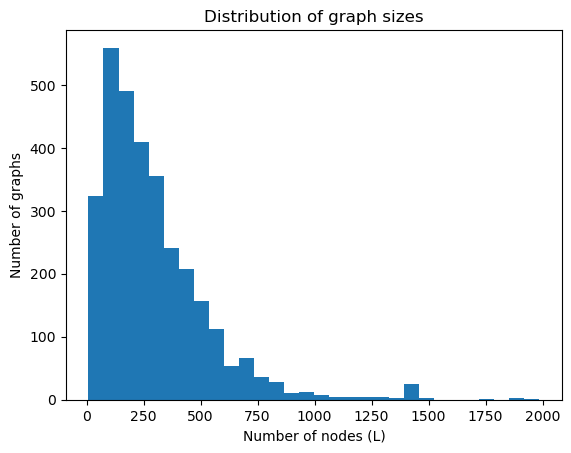

In [14]:
#distribution of the PDB in function of their lenght
all_data = torch.load("all_data_likeDCA_sep0+regression.pt",weights_only=False)   

print(f"Number of PDB:{len(all_data)}")

lengths = [data.num_nodes for data in all_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

Number of PDB:3010


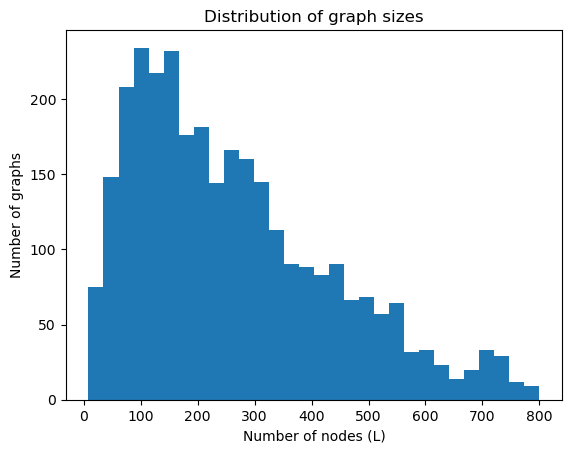

In [15]:
#biggest PDB are removed for memory cost
MAX_NODES = 800

filtered_data = [data for data in all_data if data.num_nodes <= MAX_NODES]

print(f"Number of PDB:{len(filtered_data)}")
lengths = [data.num_nodes for data in filtered_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

In [16]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_val_data, test_data = train_test_split(
    filtered_data,
    test_size=0.2,
    random_state=1
)

train_data, val_data = train_test_split(
    train_val_data,
    test_size=0.25,  
    random_state=1
)

train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
val_loader = DataLoader(val_data, batch_size=1,shuffle=True)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MP_GNN(
    num_layers=4,
    num_heads=4,
    node_in_dim=16,
    edge_in_dim=1,
    latent_dim=64
).to(device)

model_size(model)

save_path = "best_model_cc_likeDCA_sep0_attention+regression.pt"
#to load an old model
# state_dict = torch.load(save_path)
# model.load_state_dict(state_dict)

# pos_weight = torch.minimum(
#     compute_pos_weight(train_loader, device),
#     torch.tensor(8.0, device=device)
# )



# print("pos_weight:", pos_weight.item())
# loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

loss_fn = AsymmetricLoss(
    gamma_neg=8,
    gamma_pos=1
)



optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)   
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=10,min_lr=1e-6)


Total parameters:      209,602
Trainable parameters:  209,602
Non-trainable params:  0


In [18]:
def compute_loss(batch, pred_dist, true_dist):
    valid = batch.edge_mask #& batch.pair_mask

    loss = F.smooth_l1_loss(
        pred_dist[valid],
        true_dist[valid],
        beta=0.1,
        reduction='mean'
    )

    return loss

In [19]:
train_losses = []
val_losses = []


best_val_loss = float('inf')
patience = 70
epochs_no_improve = 0

for epoch in range(3000):

    model.train()

    total_loss = 0.0
    total_edges = 0
    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        pred_logits, pred_dist = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        pred_dist= pred_dist.squeeze(-1)

        true_contacts = batch.y.squeeze(-1)
        true_dist=batch.y_dist.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss_contact = loss_fn(pred_logits[mask], true_contacts[mask])

        loss_regression=compute_loss(batch,pred_dist,true_dist)
        
        loss = loss_regression + 20.0*loss_contact 

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        optimizer.step()

    train_loss = total_loss / max(total_edges, 1)

    model.eval()
    total_loss_val = 0.0
    total_edges_val = 0

    with torch.no_grad():

        loss_contact_tot=[]
        loss_regression_tot=[]
        for batch in val_loader:
            batch = batch.to(device)

            pred_logits, pred_dist = model(batch)

            pred_dist= pred_dist.squeeze(-1)
            pred_logits = pred_logits.squeeze(-1)

            true_contacts = batch.y.squeeze(-1)
            true_dist=batch.y_dist.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss_contact = loss_fn(pred_logits[mask], true_contacts[mask])
            loss_regression=compute_loss(batch,pred_dist,true_dist)

            loss = loss_regression + 20.0*loss_contact

            n_edges = mask.sum().item()
            total_loss_val += loss.item() * n_edges
            total_edges_val += n_edges

    val_loss= total_loss_val / max(total_edges_val, 1)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

Epoch 0: Train Loss=0.9118, Val Loss=0.8307
Epoch 1: Train Loss=0.7425, Val Loss=0.6779
Epoch 2: Train Loss=0.6806, Val Loss=0.6708
Epoch 3: Train Loss=0.6679, Val Loss=0.6689
Epoch 4: Train Loss=0.6589, Val Loss=0.6618
Epoch 5: Train Loss=0.6622, Val Loss=0.6485
Epoch 6: Train Loss=0.6509, Val Loss=0.6391
Epoch 7: Train Loss=0.6524, Val Loss=0.6559
Epoch 8: Train Loss=0.6459, Val Loss=0.6369
Epoch 9: Train Loss=0.7153, Val Loss=0.6790
Epoch 10: Train Loss=0.6551, Val Loss=0.6453
Epoch 11: Train Loss=0.6490, Val Loss=0.6827
Epoch 12: Train Loss=0.6599, Val Loss=0.6501
Epoch 13: Train Loss=0.6557, Val Loss=0.6385
Epoch 14: Train Loss=0.6517, Val Loss=0.6434
Epoch 15: Train Loss=0.6639, Val Loss=0.6536
Epoch 16: Train Loss=0.6594, Val Loss=0.6444
Epoch 17: Train Loss=0.6519, Val Loss=0.6520
Epoch 18: Train Loss=0.6655, Val Loss=0.6539
Epoch 19: Train Loss=0.6661, Val Loss=0.6481
Epoch 20: Train Loss=0.6451, Val Loss=0.6415
Epoch 21: Train Loss=0.6438, Val Loss=0.6749
Epoch 22: Train Loss

KeyboardInterrupt: 

In [20]:
print(optimizer.param_groups[0]['lr'])

0.00015625


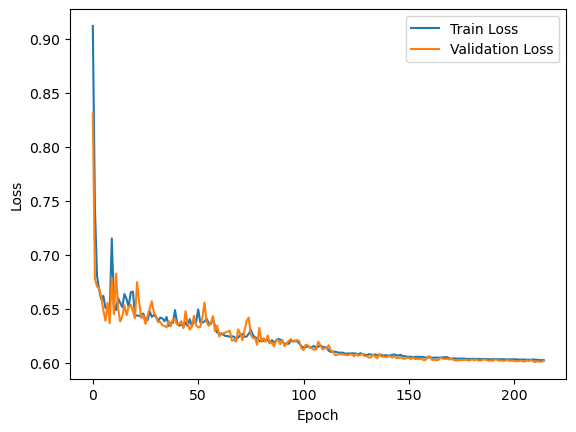

In [21]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = MP_GNN(
    num_layers=4,
    num_heads=4,
    node_in_dim=16,
    edge_in_dim=1,
    latent_dim=64
).to(device)


save_path = "best_model_cc_likeDCA_sep0_attention+regression.pt"

state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

Validation ROC AUC GNN: 0.888224121102939


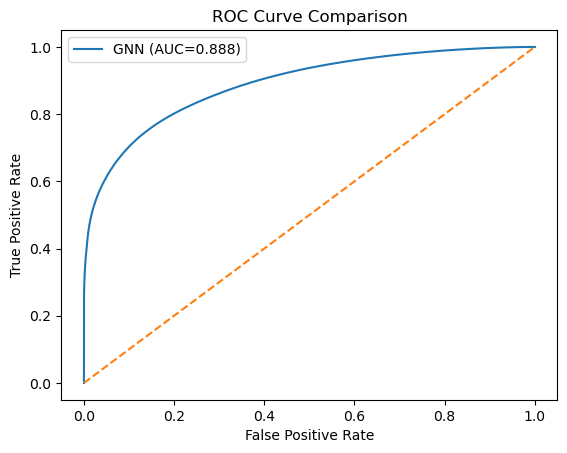

PR AUC GNN: 0.611321389818005


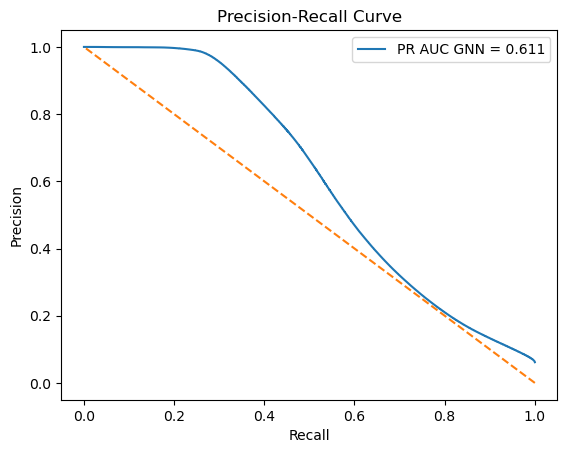

In [23]:
#ROC and Precision-Recall curve

model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        pred_logits,_ = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask

    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)


# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()
plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [24]:
print("Top-k*L precision:", topk_L_precision(model, test_loader, device, ratio=5)[0])

AttributeError: 'tuple' object has no attribute 'squeeze'

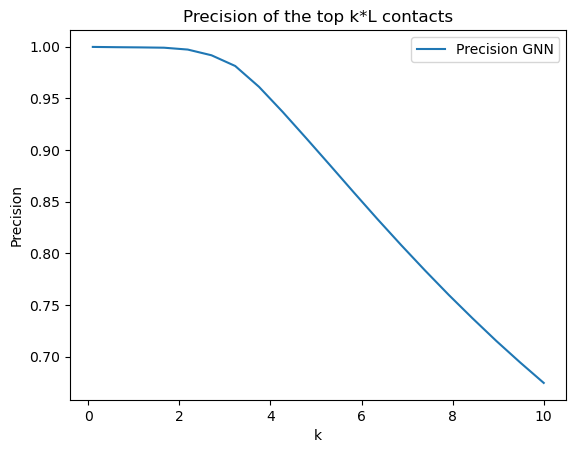

In [ ]:
#precision in function of the number of contact to predict

total_k=np.linspace(0.1,10,20)
p_GNN=[]

for k in total_k:
    prec=[]

    for batch in test_loader:
        batch = batch.to(device)

        #accuracy for a single batch
        with torch.no_grad():
            _, pred_logits = model(batch)
            scores = torch.sigmoid(pred_logits.squeeze(-1))
            

        mask = batch.edge_mask & batch.pair_mask
        scores = scores[mask]

        true_contacts = batch.y.squeeze(-1)[mask]

        L = batch.L
        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices


        topk_true = true_contacts[topk_idx]


        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec.append(precision)


    p_GNN.append(np.mean(prec))

plt.figure()

plt.plot(total_k, p_GNN, label=f"Precision GNN")


plt.xlabel("k")
plt.ylabel("Precision")
plt.title("Precision of the top k*L contacts")
plt.legend()

plt.show()

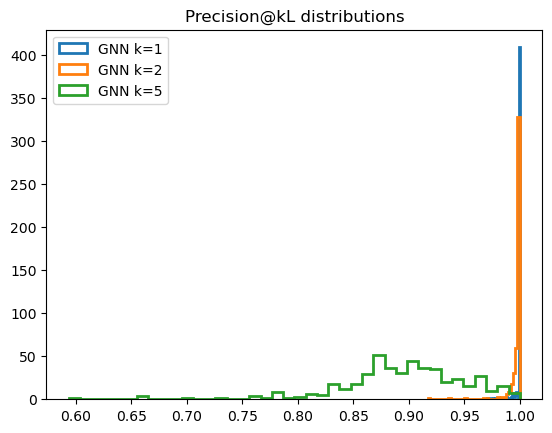

In [ ]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, histtype='step',linewidth=2, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [ ]:
k=5
precision= topk_L_precision(model, test_loader, device, ratio=k)[1]
print(precision)
print(max(precision))
print(precision.index(max(precision)))

[0.9273256063461304, 0.9956521391868591, 0.9004064798355103, 0.9315436482429504, 0.9913042783737183, 0.9058823585510254, 0.9567567706108093, 0.9714285731315613, 0.8778225779533386, 0.9666666984558105, 0.98333340883255, 0.9129186272621155, 0.9797101616859436, 0.897428572177887, 0.9117318391799927, 0.9114094376564026, 0.9438735246658325, 0.9372780919075012, 0.8931506872177124, 0.9031111001968384, 0.8940092325210571, 0.95652174949646, 0.8841345906257629, 0.8329670429229736, 0.9053571820259094, 0.9307692050933838, 0.9495652318000793, 0.9863014221191406, 0.8357663750648499, 0.9515151977539062, 0.9677419662475586, 0.9254717230796814, 0.9370558857917786, 0.9093655943870544, 0.9066666960716248, 0.896969735622406, 0.9063063263893127, 0.9043795466423035, 0.9380200505256653, 0.9021739363670349, 0.910801351070404, 0.9030172228813171, 0.9107527136802673, 0.9459119439125061, 0.971428632736206, 0.9239819049835205, 0.8942148685455322, 0.9136507511138916, 0.9407407641410828, 0.9561644196510315, 0.94838

Data(x=[151, 16], edge_index=[2, 22650], edge_attr=[22650, 1], y=[22650, 1], y_dist=[22650, 1], edge_mask=[22650], pair_mask=[22650], L=151)


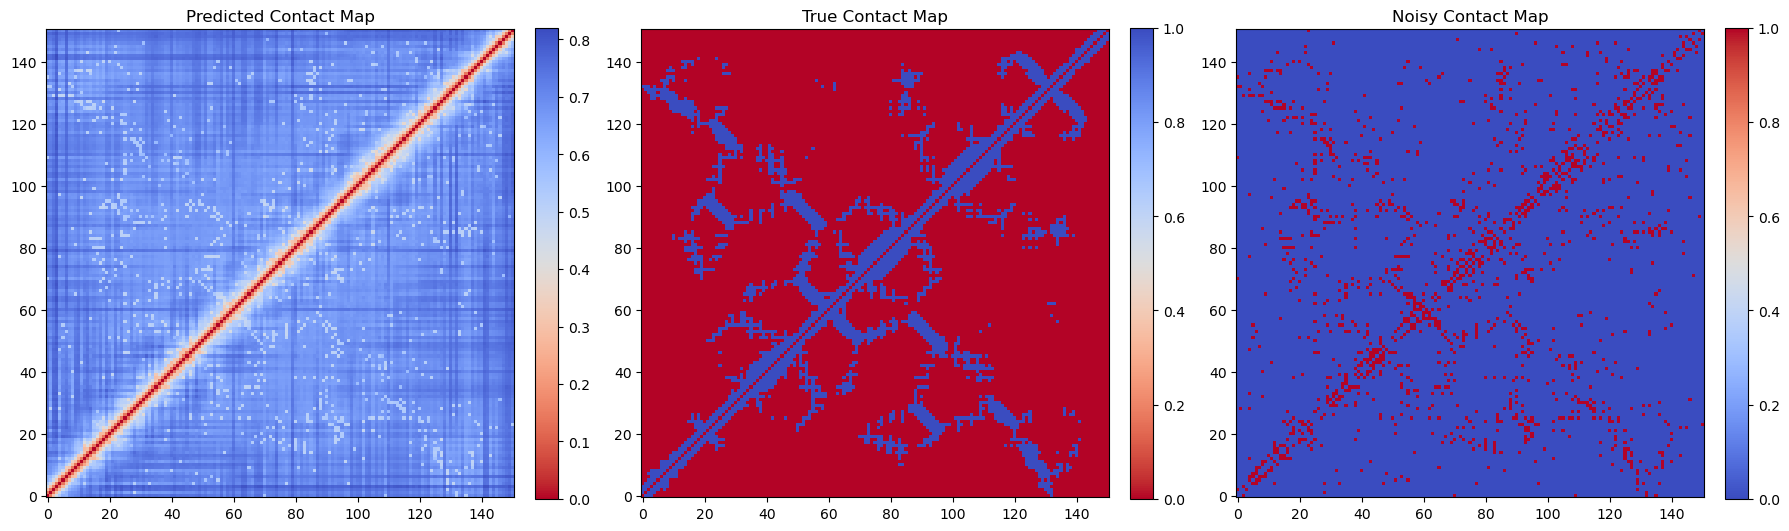

In [25]:
pos=124
#best case

i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)



scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.8
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Now we can test this on real DCA data

In [26]:
#test on DCA data

folder_path = folder_DCA

dca_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']

        #each DCA score is transformed into a contact map with 5L contacts
        k = 5*len(sequence)  
        binary_map = top_k_mask(contact_map_DCA, k)
        
        data = build_graph_contact(binary_map, distance_map)
        
        dca_data.append(data)

test_dca_loader = DataLoader(dca_data, batch_size=1, shuffle=False)

Validation ROC AUC GNN: 0.8415942001857354
Validation ROC AUC DCA: 0.7278826305419349


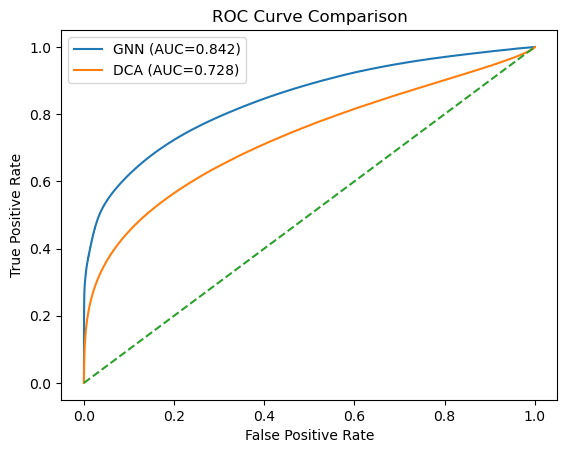

PR AUC GNN: 0.6016056247224978
PR AUC DCA: 0.40158430373699566


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


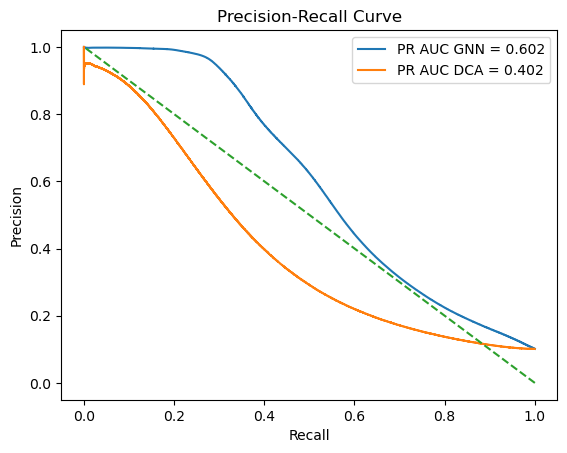

In [27]:
#DCA scores
all_scores = []
all_labels = []

min_sep=minimum_separation

folder_path = folder_DCA
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        
        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
        # Flatten
        scores = contact_map_DCA[mask].flatten()
        labels = true_contact_map[mask].flatten()

        all_scores.append(scores)
        all_labels.append(labels)

all_scores = np.concatenate(all_scores)
all_labels = np.concatenate(all_labels)


#Model scores
model.eval()

all_probs = []
all_true = []

for batch in test_dca_loader:
    batch = batch.to(device)

    with torch.no_grad():
        pred_logits,_ = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)


print("Validation ROC AUC GNN:", roc_auc)


fpr_dca, tpr_dca, _ = roc_curve(all_labels, all_scores)
roc_auc_dca = auc(fpr_dca, tpr_dca)


print("Validation ROC AUC DCA:", roc_auc_dca)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")
plt.plot(fpr_dca, tpr_dca, label=f"DCA (AUC={roc_auc_dca:.3f})")


plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)



precision_dca, recall_dca, _ = precision_recall_curve(all_labels, all_scores)
pr_auc_dca = auc(recall_dca, precision_dca)


print("PR AUC DCA:", pr_auc_dca)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot(recall_dca, precision_dca, label=f"PR AUC DCA = {pr_auc_dca:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [28]:
#precision for the GNN and DCA

#GNN precision
k=2

prec=[]

for batch in test_dca_loader:
    batch = batch.to(device)

    #accuracy for a single batch
    with torch.no_grad():
        pred_logits,_ = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
    

    mask = batch.edge_mask & batch.pair_mask
    scores = scores[mask]
    true_contacts = batch.y.squeeze(-1)[mask]

    L = batch.L
    topk = int(k * L)

    topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

    topk_true = true_contacts[topk_idx]

    num_correct = topk_true.sum()
    precision = (num_correct / len(topk_true)).item()
    prec.append(precision)
print(np.mean(prec))


#DCA precision
prec_dca=[]
min_sep = minimum_separation
folder_path=folder_DCA
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        
        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
        # Flatten and go to torch
        scores = torch.tensor(contact_map_DCA[mask].flatten(), dtype=torch.float)
        labels = torch.tensor(true_contact_map[mask].flatten(), dtype=torch.float)

        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = labels[topk_idx]

        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec_dca.append(precision)
print(np.mean(prec_dca))



0.9907160211571664
0.7527846958796082


In [30]:
#for the GNN it's possible to obtain the same with the function topk_L_precision
k=2

print("Top-k*L precision GNN:", topk_L_precision(model, test_dca_loader, device, ratio=k)[0])


Top-k*L precision GNN: 0.9711541545688915


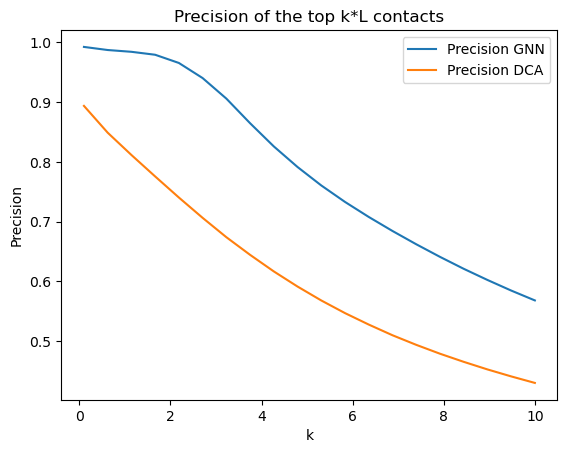

In [ ]:
#precision in function of the number of contact to predict
total_k=np.linspace(0.1,10,20)
p_GNN=[]
p_DCA=[]
for k in total_k:

    #GNN    
    prec=[]

    for batch in test_dca_loader:
        batch = batch.to(device)

        #accuracy for a single batch
        with torch.no_grad():
            _, pred_logits = model(batch)
            scores = torch.sigmoid(pred_logits.squeeze(-1))
        

        mask = batch.edge_mask & batch.pair_mask
        scores = scores[mask]
        true_contacts = batch.y.squeeze(-1)[mask]

        L = batch.L
        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = true_contacts[topk_idx]

        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec.append(precision)
    
    p_GNN.append(np.mean(prec))

    #DCA

    prec_dca=[]


    min_sep=minimum_separation

    folder_path=folder_DCA
    for file in os.listdir(folder_path):
        if file.endswith(".pkl"):
            with open(os.path.join(folder_path, file), "rb") as f:
                loaded = pickle.load(f)

            sequence = loaded['sequence']
            distance_map = loaded['distance_map']
            contact_map_DCA = loaded['dca']

            true_contact_map = contact_from_distance(distance_map, threshold=8.0)
            
            L = len(sequence)
            i, j = np.indices((L, L))

            mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
            # Flatten and go to torch
            scores = torch.tensor(contact_map_DCA[mask].flatten(), dtype=torch.float)
            labels = torch.tensor(true_contact_map[mask].flatten(), dtype=torch.float)

            topk = int(k * L)

            topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

            topk_true = labels[topk_idx]

            num_correct = topk_true.sum()
            precision = (num_correct / len(topk_true)).item()
            prec_dca.append(precision)

    p_DCA.append(np.mean(prec_dca))
    

plt.figure()

plt.plot(total_k, p_GNN, label=f"Precision GNN")
plt.plot(total_k, p_DCA, label=f"Precision DCA")


plt.xlabel("k")
plt.ylabel("Precision")
plt.title("Precision of the top k*L contacts")
plt.legend()

plt.show()

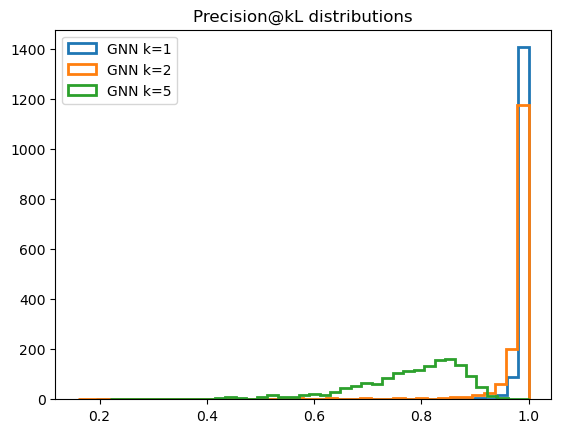

In [ ]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_dca_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, histtype='step',linewidth=2, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [ ]:
k=1
precision= topk_L_precision(model, test_dca_loader, device, ratio=k)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))
print(max(precision))
print(precision.index(max(precision)))

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9506173133850098, 1.0, 1.0, 0.9870129823684692, 1.0, 1.0, 0.9803922176361084, 0.9883138537406921, 0.997560977935791, 0.9736841917037964, 1.0, 0.9968253970146179, 0.9999999403953552, 0.9772727489471436, 0.9761905074119568, 1.0, 1.0, 0.9847328066825867, 0.9999999403953552, 0.9724137783050537, 0.9591836333274841, 0.9999999403953552, 1.0, 0.9999999403953552, 0.9787233471870422, 1.0, 0.9702702760696411, 0.9924812316894531, 1.0, 1.0, 0.9894737005233765, 1.0, 1.0, 1.0, 0.9999999403953552, 0.9631901383399963, 1.0, 1.0, 0.9806762933731079, 0.984466016292572, 0.9960000514984131, 0.9831222891807556, 1.0, 1.0, 0.9696048498153687, 0.9783950448036194, 0.9974937438964844, 0.9870129823684692, 0.9351145029067993, 0.9873418211936951, 1.0, 0.9949238300323486, 1.0, 1.0, 1.0, 0.9247311949729919, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9579832553863525, 0.9801324605941772, 1.0, 0.995555579662323, 0.9943181872367859, 1.0, 1.0, 1.0, 1.0, 0.9999999403953552, 1.0, 0.967741906642913

Data(x=[65, 16], edge_index=[2, 4160], edge_attr=[4160, 1], y=[4160, 1], y_dist=[4160, 1], edge_mask=[4160], pair_mask=[4160], L=65)


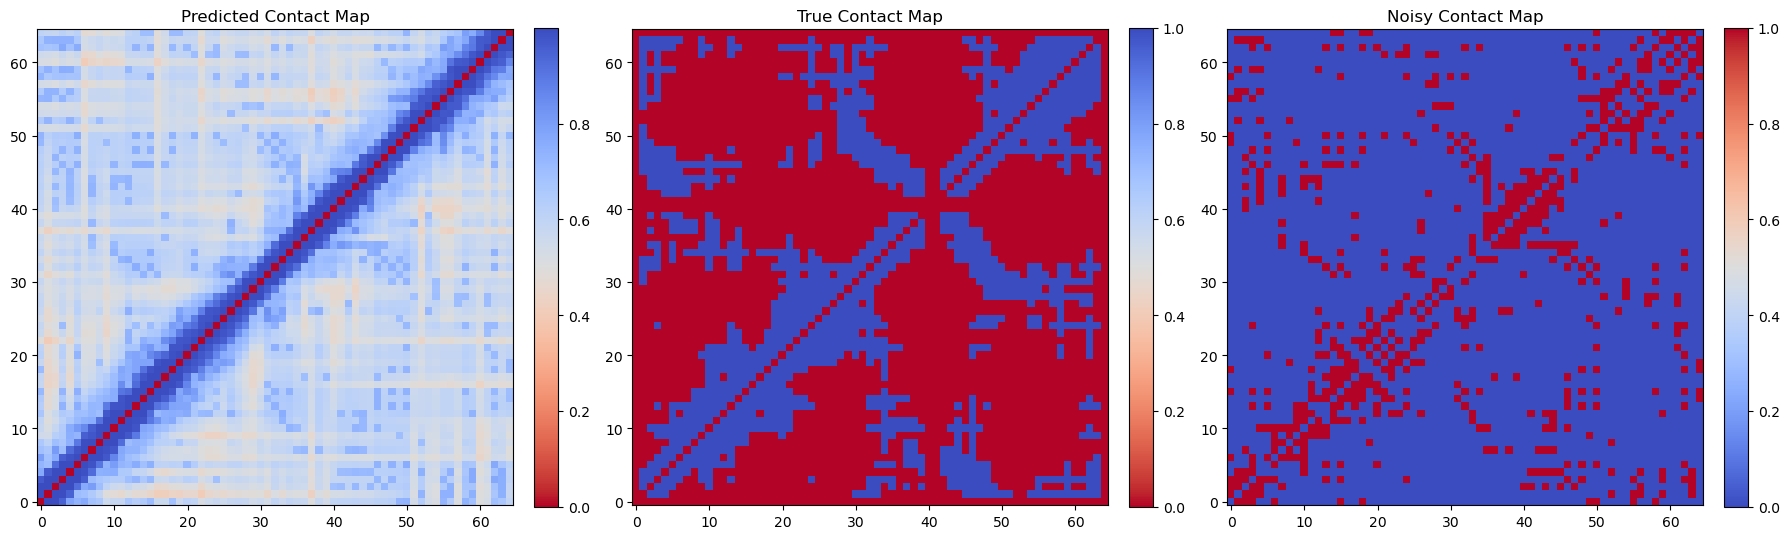

In [32]:
pos=0


i=0
with torch.no_grad():
    for batch in test_dca_loader:
        if i==pos:
            batch = batch.to(device)
            pred_logits,_ = model(batch)
        i+=1

batch=dca_data[pos]
print(batch)

mask = batch.edge_mask #& batch.pair_mask

scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.9
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Data(x=[104, 16], edge_index=[2, 10712], edge_attr=[10712, 1], y=[10712, 1], edge_mask=[10712], pair_mask=[10712], L=104)


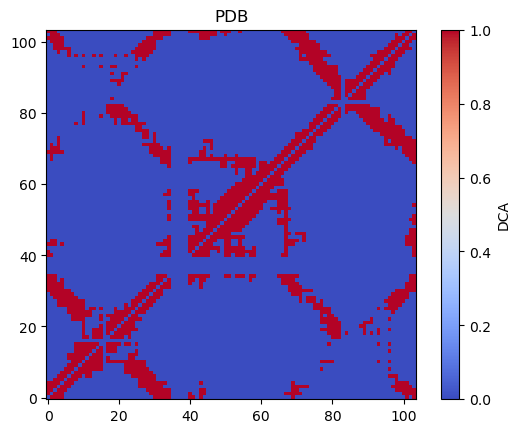

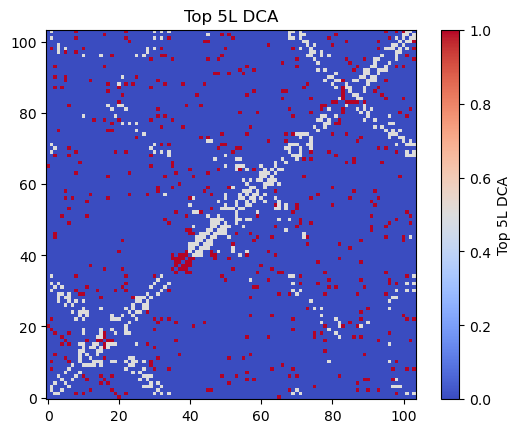

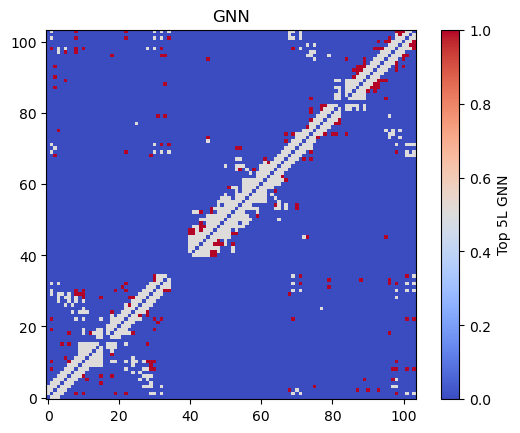

TP: 412, FP: 108, Precision GNN @ 5: 0.7923


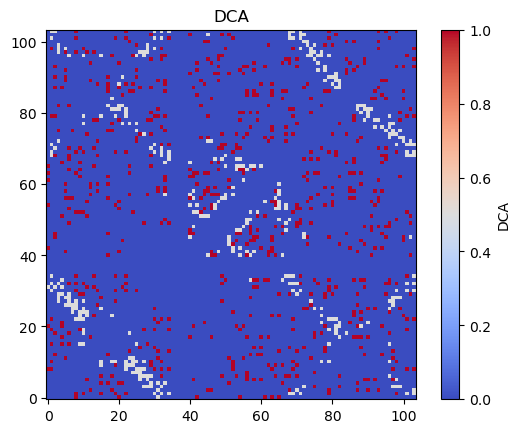

TP: 178, FP: 342, Precision DCA @5: 0.3423


In [ ]:
#non guardare, vari tentativi per capire come si sta comportando il modello su un singolo esempio

pos=3

#changing k it's possible to visualize the top kL prediction and to see if they are good or not
k=5


i=0
with torch.no_grad():
    for batch in test_dca_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=dca_data[pos]
print(batch)

mask = batch.edge_mask #& batch.pair_mask
mask_matrix = graph_to_matrix(batch, mask.squeeze(-1).cpu().float())

L= batch.L

scores = torch.sigmoid(pred_logits.squeeze(-1))
pred_contact_map = graph_to_matrix(batch, scores.cpu())


new_map = top_k_mask(pred_contact_map, int(k* L), mask=mask_matrix).astype(np.float32)
contact_map = graph_to_matrix(batch, batch.y.cpu()).numpy()
noisy_contact_map = graph_to_matrix(batch, batch.edge_attr.cpu()).numpy()



#original pdb
plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("PDB")
plt.show()


#top 5L dca (as in the training)
true_positives = (noisy_contact_map == 1) & (contact_map == 1)
false_positives = (noisy_contact_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] == 1:# and mask_matrix[i][j] == 1   :
            result[i][j] = 0.5
        elif false_positives[i][j] == 1:# and mask_matrix[i][j]  == 1:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
plt.colorbar(label="Top 5L DCA")
plt.title("Top 5L DCA")
plt.show()


#graph predicted from GNN (top kL)
true_positives = (new_map == 1) & (contact_map == 1)
false_positives = (new_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] and mask_matrix[i][j] == 1:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and mask_matrix[i][j] == 1:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
plt.colorbar(label="Top 5L GNN")
plt.title("GNN")
plt.show()






# precision of GNN

edge_mask = (batch.edge_mask & batch.pair_mask)

scores_flat = scores[edge_mask]
true_flat = batch.y.squeeze(-1)[edge_mask]

kappa = int(k * L)
kappa = min(kappa, scores_flat.numel())

topk_idx = torch.topk(scores_flat, k=kappa).indices.cpu()
topk_true = true_flat[topk_idx]

precision = topk_true.float().mean().item()
tp = (topk_true > 0.5).sum().item()
fp = kappa - tp

print(f"TP: {tp}, FP: {fp}, Precision GNN @ {k}: {precision:.4f}")



##graph predicted from DCA (top kL)


i=0
folder_path="Data"
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)
        if i==pos:
            sequence = loaded['sequence']
            distance_map = loaded['distance_map']
            contact_map_DCA = loaded['dca']
            break
        i+=1

true_contact_map = contact_from_distance(distance_map, threshold=8.0)
            
L = len(sequence)
i, j = np.indices((L, L))

mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
# Flatten and go to torch
scores = torch.tensor(contact_map_DCA[mask].flatten(), dtype=torch.float)
labels = torch.tensor(true_contact_map[mask].flatten(), dtype=torch.float)

topk = int(k * L)

topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices
# build full L×L map
new_map = np.zeros(mask.shape, dtype=np.float32)

flat_indices = np.flatnonzero(mask)  # positions in original matrix

selected_positions = flat_indices[topk_idx.cpu().numpy()]

# convert flat indices back to 2D
rows, cols = np.unravel_index(selected_positions, mask.shape)

new_map[rows, cols] = 1.0
new_map[cols, rows] = 1.0  # if symmetric contacts


true_positives = (new_map == 1) & (contact_map == 1)
false_positives = (new_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] and mask_matrix[i][j] == 1:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and mask_matrix[i][j] == 1:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA")
plt.show()



#precision DCA
topk_true = labels[topk_idx]

precision = topk_true.float().mean().item()
tp = (topk_true > 0.5).sum().item()
fp = kappa - tp

print(f"TP: {tp}, FP: {fp}, Precision DCA @{k}: {precision:.4f}")


In [34]:
#we want to see if the prediction for not near-diagonal terms have been improved or not
min_sep = 5
k = 0.5



prec = []

for batch in test_dca_loader:
    batch = batch.to(device)

    with torch.no_grad():
        pred_logits,_ = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
        
    # keep only valid pairs and exclude diagonal / near-diagonal pairs
    sep_mask = (batch.edge_index[0] - batch.edge_index[1]).abs() >= min_sep
    upper_mask = batch.edge_index[0] < batch.edge_index[1]
    mask = batch.edge_mask & batch.pair_mask & sep_mask & upper_mask

    scores = scores[mask]
    true_contacts = batch.y.squeeze(-1)[mask]

    L = batch.L
    topk = int(k * L)

    if scores.numel() == 0:
        continue

    topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

    topk_true = true_contacts[topk_idx]


    precision = topk_true.float().mean().item() if len(topk_true) > 0 else 0.0


    prec.append(precision)

print(f"Precision of the GNN: {np.mean(prec)}")



prec=[]
folder_path=folder_DCA
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        
        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
        # Flatten
        scores = torch.tensor(contact_map_DCA[mask].flatten())
        labels = torch.tensor(true_contact_map[mask].flatten())

        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = labels[topk_idx]

        precision = topk_true.float().mean().item() if len(topk_true) > 0 else 0.0

        prec.append(precision)



print(f"Precision of the DCA: {np.mean(prec)}")

Precision of the GNN: 0.6028084608414171
Precision of the DCA: 0.7265766032474458
